# Instalar paquetes

1.- instalar anaconda y que se pueda usar por consola

> https://docs.conda.io/projects/conda/en/latest/user-guide/install/windows.html

2.- Una vez instalado, crear un entorno con los paquetes necesarios (usar el archivo caic.yml)

> conda create -f caic.yml

2.5.- En caso de que falle el archivo (ya que lo exporte de la mac), se necesitan hacer manualmente el entorno

2.5.1.- Crear el entorno

```
conda create --name caic python=3.12
```

2.5.2.- Activar el entorno creado

```
conda activate caic
```

2.5.3.- bajar los paquetes por anaconda

```
conda install numpy pandas matplotlib pytorch torchvision torchaudio scipy scikit-learn ipykernel -c conda-forge
```

2.5.4.- para el fis/difuso se ocupa una librería que no esta en conda, utilizar pip

```
pip instal fuzzylab
```

3.- En notebook, cambiar el kernel al entorno creado (caic)

4.- Ejecutar las celdas de este notebook

# Librerías

In [1]:
#para el modelo
from Anfis_utils import CargarFIS,CrearFISInicial,GuardarFIS
from V2_Anfis import RLANFISBuilder,train_nfs,LevenberMaquardtOpt,Optimizador,cantidad_reglas
from funciones_auxiliares import OneHotEncode,PlotTraining, confusion_matrix


In [2]:
# para cargar el dataset
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.model_selection import train_test_split

# Cargar Data sets

### Config

In [3]:
test_size = 0.4
val_size = test_size/2

## Simple fit Data Set

In [4]:
#todos los datos
simplefit_data = loadmat("data_sets/simple_fit.mat")
simplefit_int = np.array(simplefit_data['inputs'])
simplefit_out = np.array(simplefit_data['targets'])

#separarlos en entrenamiento,validación y prueba
simplefit_X_train, simplefit_X_val, simplefit_y_train, simplefit_y_val = train_test_split(simplefit_int.T, 
                                                                                        simplefit_out.T, 
                                                                                        test_size=test_size,)
simplefit_XTEST, simplefit_XVAL, simplefit_YTEST, simplefit_YVAL = train_test_split(simplefit_X_val, 
                                                                                    simplefit_y_val,
                                                                                    test_size=val_size)



### Encontrar la cantidad de reglas

/Users/omarzamarron/Documents/python/DemoSukey/Anfis_utils.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  a = (rango[e,1] - rango[e, 0])/2/(mf_n[e] - 1);


Cargando FIS
Entradas: 1 Salidas: 1 Reglas:1
sigma: torch.Size([1, 1])
centro: torch.Size([1, 1])
theta: torch.Size([1, 1])
MSELoss()
Inputs: torch.Size([56, 1]) , Outputs: torch.Size([56, 1])
Epoch 0, Loss: 554.823915
[16] El modelo llego a las mu maximas 7.3E+10 >= 1.0E+10(True)
[16] con un loss de 554.823856
Cargando FIS
Entradas: 1 Salidas: 1 Reglas:2
sigma: torch.Size([1, 2])
centro: torch.Size([1, 2])
theta: torch.Size([2, 1])
MSELoss()
Inputs: torch.Size([56, 1]) , Outputs: torch.Size([56, 1])
Epoch 0, Loss: 213.727829
Epoch 100, Loss: 72.196124
[112] El modelo llego a las mu maximas 4.5E+10 >= 1.0E+10(True)
[112] con un loss de 72.196124
Cargando FIS
Entradas: 1 Salidas: 1 Reglas:3
sigma: torch.Size([1, 3])
centro: torch.Size([1, 3])
theta: torch.Size([3, 1])
MSELoss()
Inputs: torch.Size([56, 1]) , Outputs: torch.Size([56, 1])
Epoch 0, Loss: 155.152018
Epoch 100, Loss: 93.340161
Epoch 200, Loss: 93.338148
Epoch 300, Loss: 93.337458
Epoch 400, Loss: 93.337006
Epoch 500, Loss: 93

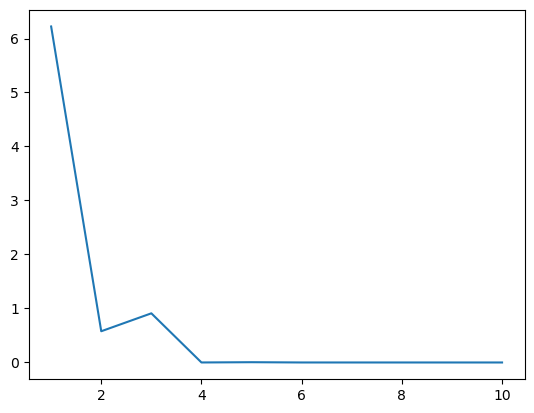

In [5]:
s_best_reglas, s_log = cantidad_reglas(entradas=1,
                                        salidas=1,
                                        n_clases=None,
                                        r_inicial=1,
                                        r_final=10,
                                        x_train=simplefit_X_train,
                                        y_train=simplefit_y_train,
                                        x_test=simplefit_XTEST,
                                        y_test=simplefit_YTEST)

print(f"Mejor cantidad de reglas: {s_best_reglas}")
plt.plot(range(1,11),s_log)

### Config FIS Simple Fit

In [6]:
#Configuración del FIS=  
simplefit_n_in = 1
simplefit_n_out =  1    
simplefit_k_reglas = 4 #en este caso se puede tomar 4 o el mejor ya que no hay mucha diferencia
simplefit_fis,simplefit_fis_str = CrearFISInicial("simplefit", 
                                                pd.DataFrame(simplefit_int.T),
                                                pd.DataFrame(simplefit_out.T),
                                                simplefit_k_reglas)

### Convertir la entrada y salida en datos Tensores de pytorch

In [7]:
simplefit_X = torch.from_numpy(simplefit_X_train).to(torch.float64)
simplefit_X_test = torch.from_numpy(simplefit_XTEST).to(torch.float64)

simplefit_X_VAL = torch.from_numpy(simplefit_XVAL).to(torch.float64)
simplefit_Y_VAL = torch.from_numpy(simplefit_YVAL).to(torch.float64)

simplefit_Y = torch.from_numpy(simplefit_y_train).to(torch.float64)
simplefit_Y_test = torch.from_numpy(simplefit_YTEST).to(torch.float64)

### Creamos Modelo neuro difuso

### Optimizadores

In [8]:
SGD = torch.optim.SGD #lr=0.001,momentum=0,weight_decay=0,nesterov=False
Adam = torch.optim.Adam #lr=0.001,betas=(0.9, 0.999),eps=1e-08,weight_decay=0,amsgrad=False
RMSprop = torch.optim.RMSprop #lr=0.001,alpha=0.99,eps=1e-08,weight_decay=0,momentum=0,centered=False
LM = LevenberMaquardtOpt #lambda_init=0.01,lambda_decr=0.9,lambda_incr=10

### Funciones de perdida

In [9]:
MAE = torch.nn.L1Loss()
MSE = torch.nn.MSELoss()
SSE = lambda output, target: torch.sum((output - target) ** 2)


### Modelo

In [10]:
""" Diferentes optimizadores
.AddOptimizador(SGD, lr=0.001,momentum=0,weight_decay=0,nesterov=False)
.AddOptimizador(RMSprop, lr=0.001,alpha=0.99,eps=1e-08,weight_decay=0,momentum=0,centered=False)
.AddOptimizador(Adam, lr=0.001,betas=(0.9,0.99),eps=1e-8) 
.AddOptimizador(LM, lambda_init=0.01,lambda_decr=0.9,lambda_incr=10) 

.AddFunctionLoss(MAE)
.AddFunctionLoss(MSE)
.AddFunctionLoss(SSE)
"""


simplefit_anfis_model =   RLANFISBuilder() \
                    .AddFIS(simplefit_fis_str) \
                    .AddInputs(simplefit_n_in) \
                    .AddOutputs(simplefit_n_out) \
                    .AddRules(simplefit_k_reglas) \
                    .AddValMaxFails(20) \
                    .AddTipoProblema("regresion") \
                    .AddOptimizador(LM, lambda_init=0.01,lambda_decr=0.9,lambda_incr=10)    \
                    .AddFunctionLoss(MSE) \
                    .Build()

simplefit_sgd_model =  RLANFISBuilder() \
                    .AddFIS(simplefit_fis_str) \
                    .AddInputs(simplefit_n_in) \
                    .AddOutputs(simplefit_n_out) \
                    .AddRules(simplefit_k_reglas) \
                    .AddValMaxFails(20) \
                    .AddTipoProblema("regresion") \
                    .AddOptimizador(SGD, lr=0.001,momentum=0,weight_decay=0,nesterov=False)\
                    .AddFunctionLoss(MSE) \
                    .Build()

Cargando FIS
Entradas: 1 Salidas: 1 Reglas:4
sigma: torch.Size([1, 4])
centro: torch.Size([1, 4])
theta: torch.Size([4, 1])
MSELoss()
Cargando FIS
Entradas: 1 Salidas: 1 Reglas:4
sigma: torch.Size([1, 4])
centro: torch.Size([1, 4])
theta: torch.Size([4, 1])
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
MSELoss()


### Entrenamos el modelo

Inputs: torch.Size([56, 1]) , Outputs: torch.Size([56, 1])
Epoch 0, Loss: 180.579581
Epoch 100, Loss: 46.502196
Epoch 200, Loss: 0.026863
Epoch 300, Loss: 0.015212
[372] El modelo llego a las mu maximas 1.8E+10 >= 1.0E+10(True)
[372] con un loss de 0.015067
Inputs: torch.Size([56, 1]) , Outputs: torch.Size([56, 1])
Epoch 0, Loss: 42.755764
Epoch 100, Loss: 39.181121
Epoch 200, Loss: 35.904619
Epoch 300, Loss: 32.869258
Epoch 400, Loss: 30.022038
Epoch 500, Loss: 27.306317
Epoch 600, Loss: 24.652831
Epoch 700, Loss: 21.973213
Epoch 800, Loss: 19.197913
Epoch 900, Loss: 16.474602


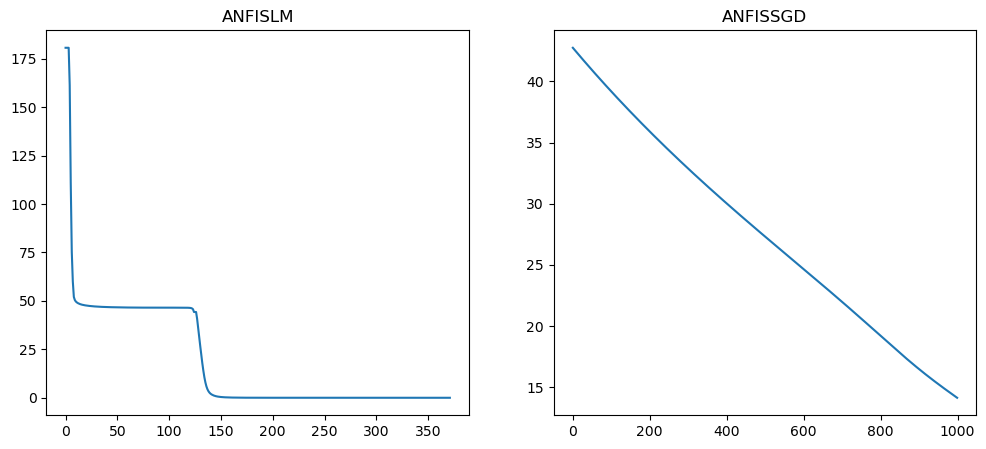

In [11]:
simplefit_loss = train_nfs(simplefit_anfis_model,       #modelo
                        simplefit_X,                    #datos entrada
                        simplefit_Y,                    #datos target
                        epochs=1000,                    #número de épocas
                        tolerancia=1e-12)               #tolerancia del error

simplefit_sgd_loss = train_nfs(simplefit_sgd_model,     #modelo
                        simplefit_X,                    #datos entrada
                        simplefit_Y,                    #datos target
                        epochs=1000,                    #número de épocas
                        tolerancia=1e-12)               #tolerancia del error

fig, axis = plt.subplots(1,2,figsize=(12,5))
axis[0].set_title("ANFISLM")
axis[0].plot(simplefit_loss)
axis[1].set_title("ANFISSGD")
axis[1].plot(simplefit_sgd_loss)
plt.show()

### Mostramos resultados

Resultados con LM
SSE = 6.340309E-03
MSE = 2.113436E-04
R = 0.9999828899247104
R^2 = 0.9999656234866391


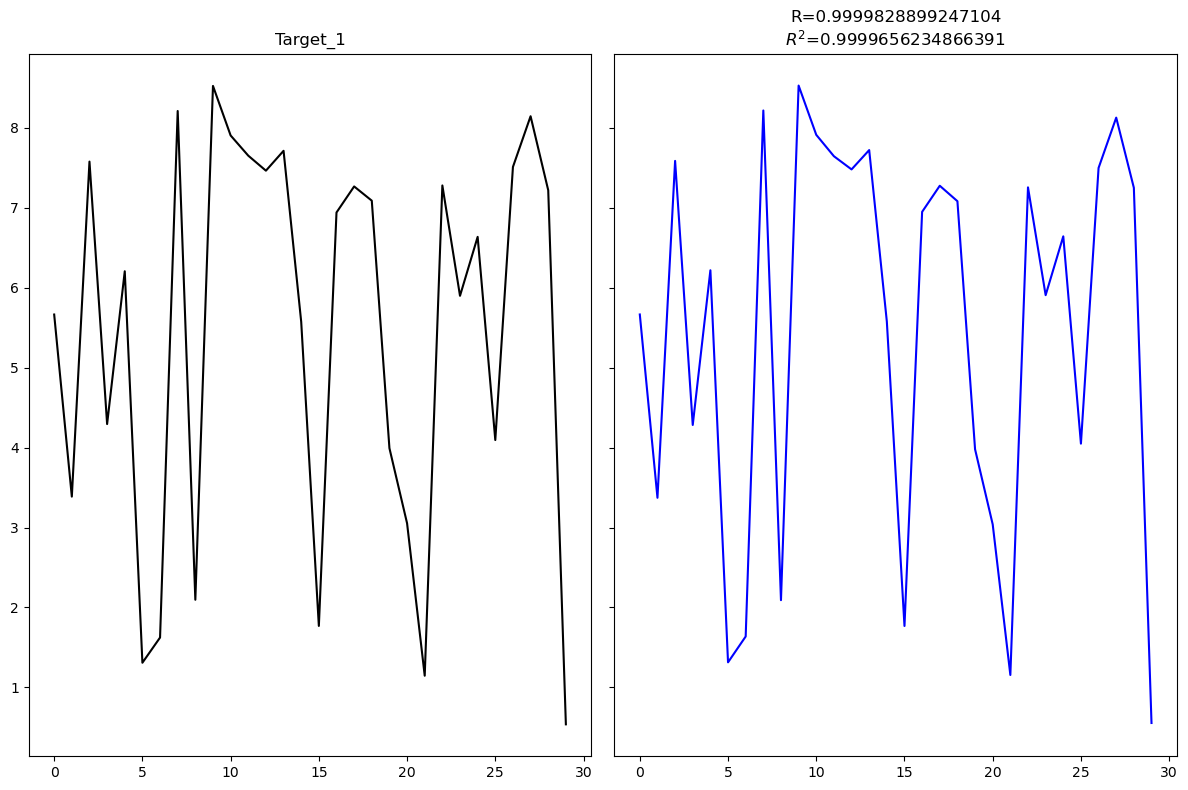

Resultados con SGD
SSE = 3.093650E+02
MSE = 1.031217E+01
R = 0.8185912565779898
R^2 = -0.6773456220355509


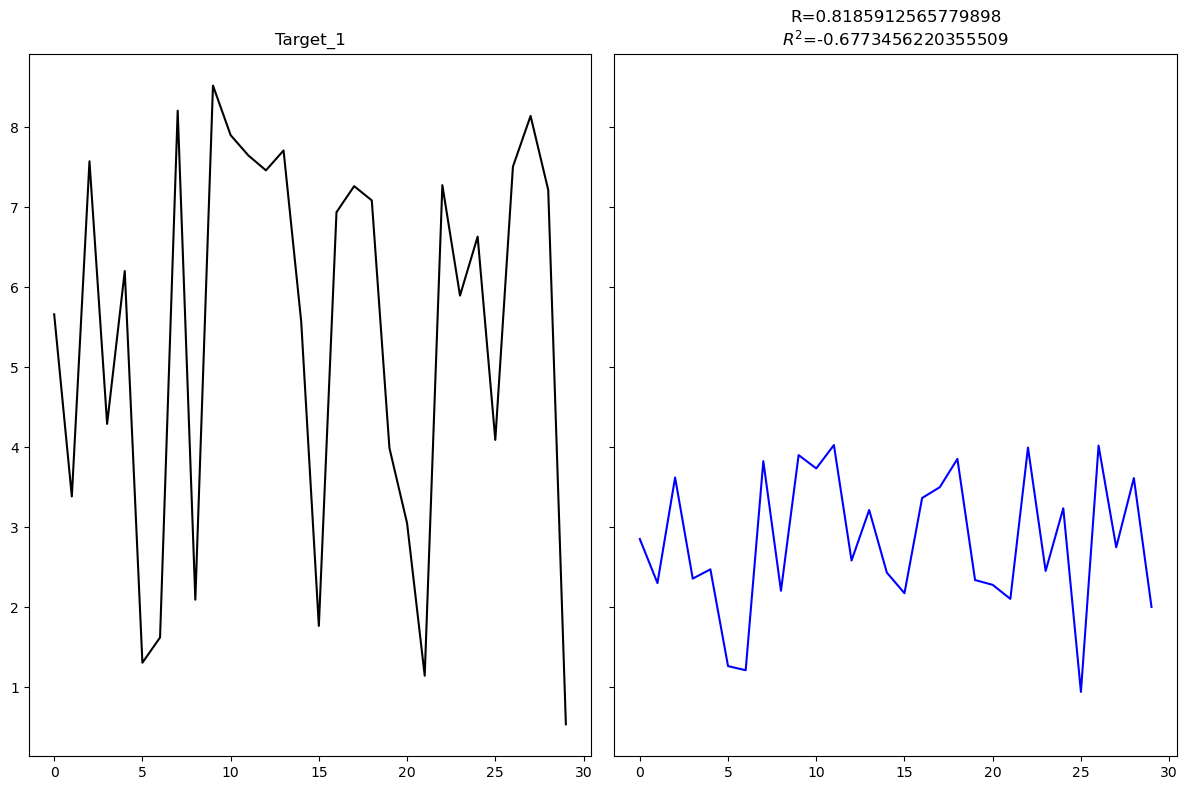

In [12]:
fnom = simplefit_fis_str.split("__")[0]
GuardarFIS(fnom+"__final.fis",fis=simplefit_fis,modelo=simplefit_anfis_model)

print("Resultados con LM")
y_hat = simplefit_anfis_model(simplefit_X_test)
PlotTraining(simplefit_X_test,y_hat,simplefit_Y_test)

print("Resultados con SGD")
y_hat_sgd = simplefit_sgd_model(simplefit_X_test)
PlotTraining(simplefit_X_test,y_hat_sgd,simplefit_Y_test)


## Engine Data set

In [13]:
#todos los datos
engine_in = loadmat("data_sets/engineInputs.mat")
engine_tar = loadmat("data_sets/engineTargets.mat")
engine_in = np.array(engine_in["engineInputs"])
engine_tar = np.array(engine_tar["engineTargets"])

#separarlos en entrenamiento,validación y prueba
engine_X_train, engine_X_val, engine_y_train, engine_y_val = train_test_split(engine_in.T, 
                                                                            engine_tar.T, 
                                                                            test_size=test_size,)
engine_XTEST, engine_XVAL, engine_YTEST, engine_YVAL = train_test_split(engine_X_val, 
                                                                        engine_y_val,
                                                                        test_size=val_size)

### Encontrar la mejor reglas

Cargando FIS
Entradas: 2 Salidas: 2 Reglas:1
sigma: torch.Size([2, 1])
centro: torch.Size([2, 1])
theta: torch.Size([1, 2])
MSELoss()
Inputs: torch.Size([719, 2]) , Outputs: torch.Size([719, 2])
Epoch 0, Loss: 375816194.716029


/Users/omarzamarron/Documents/python/DemoSukey/Anfis_utils.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  a = (rango[e,1] - rango[e, 0])/2/(mf_n[e] - 1);


[15] El modelo llego a las mu maximas 8.1E+10 >= 1.0E+10(True)
[15] con un loss de 375816194.557339
Cargando FIS
Entradas: 2 Salidas: 2 Reglas:2
sigma: torch.Size([2, 2])
centro: torch.Size([2, 2])
theta: torch.Size([2, 2])
MSELoss()
Inputs: torch.Size([719, 2]) , Outputs: torch.Size([719, 2])
Epoch 0, Loss: 215386911.898880
Epoch 100, Loss: 55775519.989992
Epoch 200, Loss: 55775240.735611
Epoch 300, Loss: 55775184.174993
Epoch 400, Loss: 55775166.176078
Epoch 500, Loss: 55775158.054616
Epoch 600, Loss: 55775156.160162
[633] El modelo llego a las mu maximas 7.3E+10 >= 1.0E+10(True)
[633] con un loss de 55775156.157120
Cargando FIS
Entradas: 2 Salidas: 2 Reglas:3
sigma: torch.Size([2, 3])
centro: torch.Size([2, 3])
theta: torch.Size([3, 2])
MSELoss()
Inputs: torch.Size([719, 2]) , Outputs: torch.Size([719, 2])
Epoch 0, Loss: 221758518.315598
Epoch 100, Loss: 14461763.855325
Epoch 200, Loss: 14393847.927305
Epoch 300, Loss: 14382586.931893
Epoch 400, Loss: 14369230.890197
Epoch 500, Loss

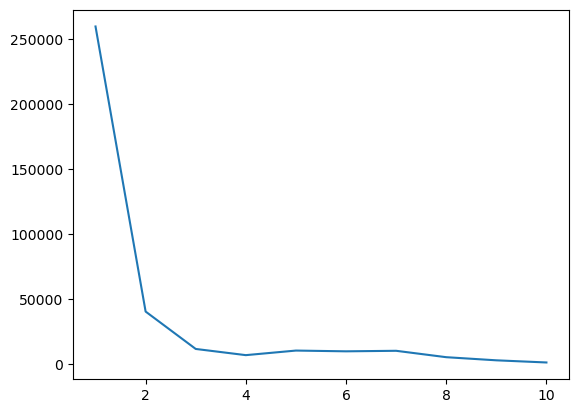

In [14]:
engine_best_reglas, engine_log = cantidad_reglas(entradas=2,
                                                salidas=2,
                                                n_clases=None,
                                                r_inicial=1,
                                                r_final=10,
                                                x_train=engine_X_train,
                                                y_train=engine_y_train,
                                                x_test=engine_XTEST,
                                                y_test=engine_YTEST)

print(f"Mejor cantidad de reglas: {engine_best_reglas}")
plt.plot(range(1,11),engine_log)

### Configurar FIS Engine

In [15]:
engine_n_in = 2
engine_n_out =  2    
engine_k_reglas = engine_best_reglas #o bien podemos usar 3 ya que es el punto del codo donde se estabiliza el error  
engine_fis,engine_fis_str = CrearFISInicial("engine", 
                                                pd.DataFrame(engine_in.T),
                                                pd.DataFrame(engine_tar.T),
                                                engine_k_reglas)

### Convertir la entrada y target a tensores pytorch

In [16]:
engine_X = torch.from_numpy(engine_X_train).to(torch.float64)
engine_X_test = torch.from_numpy(engine_XTEST).to(torch.float64)

engine_X_VAL = torch.from_numpy(engine_XVAL).to(torch.float64)
engine_Y_VAL = torch.from_numpy(engine_YVAL).to(torch.float64)

engine_Y = torch.from_numpy(engine_y_train).to(torch.float64)
engine_Y_test = torch.from_numpy(engine_YTEST).to(torch.float64)

### Creamos el modelo neuro difuso de Engine

In [17]:
""" Diferentes optimizadores
.AddOptimizador(SGD, lr=0.001,momentum=0,weight_decay=0,nesterov=False)
.AddOptimizador(RMSprop, lr=0.001,alpha=0.99,eps=1e-08,weight_decay=0,momentum=0,centered=False)
.AddOptimizador(Adam, lr=0.001,betas=(0.9,0.99),eps=1e-8) 
.AddOptimizador(LM, lambda_init=0.01,lambda_decr=0.9,lambda_incr=10) 

.AddFunctionLoss(MAE)
.AddFunctionLoss(MSE)
.AddFunctionLoss(SSE)
"""

engine_anfis_model =   RLANFISBuilder() \
                    .AddFIS(engine_fis_str) \
                    .AddInputs(engine_n_in) \
                    .AddOutputs(engine_n_out) \
                    .AddRules(engine_k_reglas) \
                    .AddValMaxFails(20) \
                    .AddTipoProblema("regresion") \
                    .AddOptimizador(LM, lambda_init=0.01,lambda_decr=0.9,lambda_incr=10)  \
                    .AddFunctionLoss(MSE) \
                    .Build()

engine_adam_model =   RLANFISBuilder() \
                    .AddFIS(engine_fis_str) \
                    .AddInputs(engine_n_in) \
                    .AddOutputs(engine_n_out) \
                    .AddRules(engine_k_reglas) \
                    .AddValMaxFails(20) \
                    .AddTipoProblema("regresion") \
                    .AddOptimizador(Adam, lr=0.001,betas=(0.9,0.99),eps=1e-8)  \
                    .AddFunctionLoss(MSE) \
                    .Build()

Cargando FIS
Entradas: 2 Salidas: 2 Reglas:10
sigma: torch.Size([2, 10])
centro: torch.Size([2, 10])
theta: torch.Size([10, 2])
MSELoss()
Cargando FIS
Entradas: 2 Salidas: 2 Reglas:10
sigma: torch.Size([2, 10])
centro: torch.Size([2, 10])
theta: torch.Size([10, 2])
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.99)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
MSELoss()


### Entrenamos el modelo

Inputs: torch.Size([719, 2]) , Outputs: torch.Size([719, 2])
Epoch 0, Loss: 188207893.076345
Epoch 100, Loss: 3556839.500803
Epoch 200, Loss: 2114971.311389
Epoch 300, Loss: 2089639.085856
Epoch 400, Loss: 2063468.299453
Epoch 500, Loss: 1893495.023791
Epoch 600, Loss: 1883761.256244
Epoch 700, Loss: 1849580.826182
Epoch 800, Loss: 1840053.523585
Epoch 900, Loss: 1830720.360298
Inputs: torch.Size([719, 2]) , Outputs: torch.Size([719, 2])
Epoch 0, Loss: 1010765.460278
Epoch 100, Loss: 1010593.450522
Epoch 200, Loss: 1010421.198042
Epoch 300, Loss: 1010248.627522
Epoch 400, Loss: 1010075.829833
Epoch 500, Loss: 1009902.850634
Epoch 600, Loss: 1009729.699274
Epoch 700, Loss: 1009556.411892
Epoch 800, Loss: 1009383.024017
Epoch 900, Loss: 1009209.557368


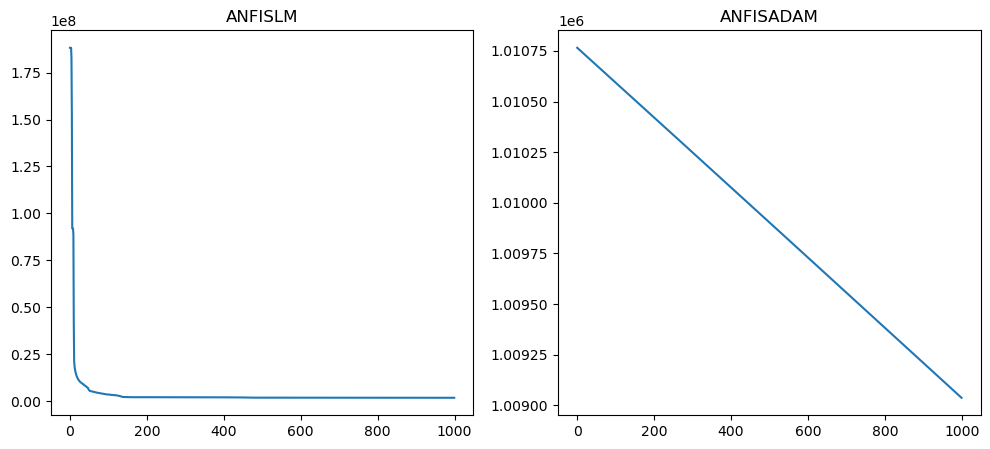

In [18]:
engine_loss = train_nfs(engine_anfis_model,         #modelo
                        engine_X,                   #datos entrada
                        engine_Y,                   #datos target
                        epochs=1000,                #número de épocas
                        tolerancia=1e-12)           #tolerancia del error

engine_adam_loss = train_nfs(engine_adam_model,         #modelo
                        engine_X,                   #datos entrada
                        engine_Y,                   #datos target
                        epochs=1000,                #número de épocas
                        tolerancia=1e-12)           #tolerancia del error

fig, axis = plt.subplots(1,2,figsize=(12,5))
axis[0].set_title("ANFISLM")
axis[0].plot(engine_loss)
axis[1].set_title("ANFISADAM")
axis[1].plot(engine_adam_loss)
plt.show()

### Mostramos resultados

Resultados con LM
SSE = 1.083108E+06
MSE = 2.820595E+03
R = 0.9974052924175849
R^2 = 0.9948102619618955


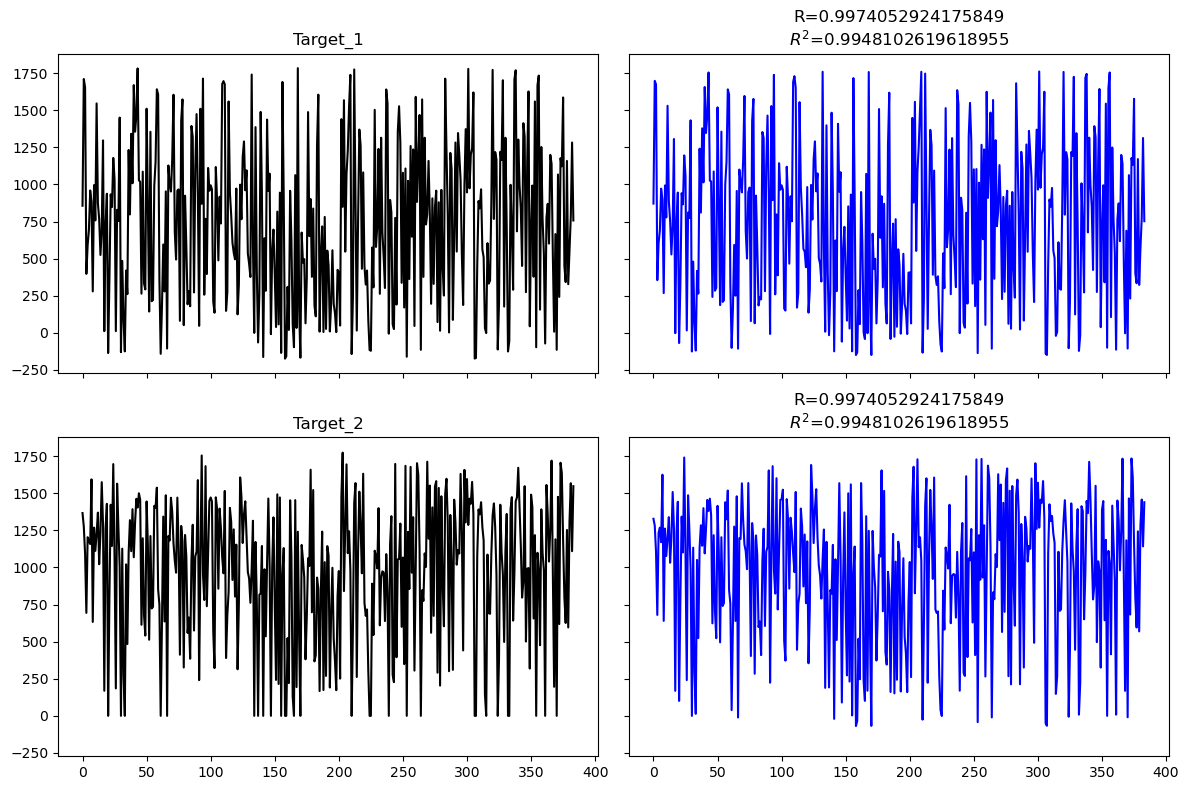

Resultados con ADAM
SSE = 7.691459E+08
MSE = 2.002984E+06
R = -0.19828150591783567
R^2 = -2.6853793218054016


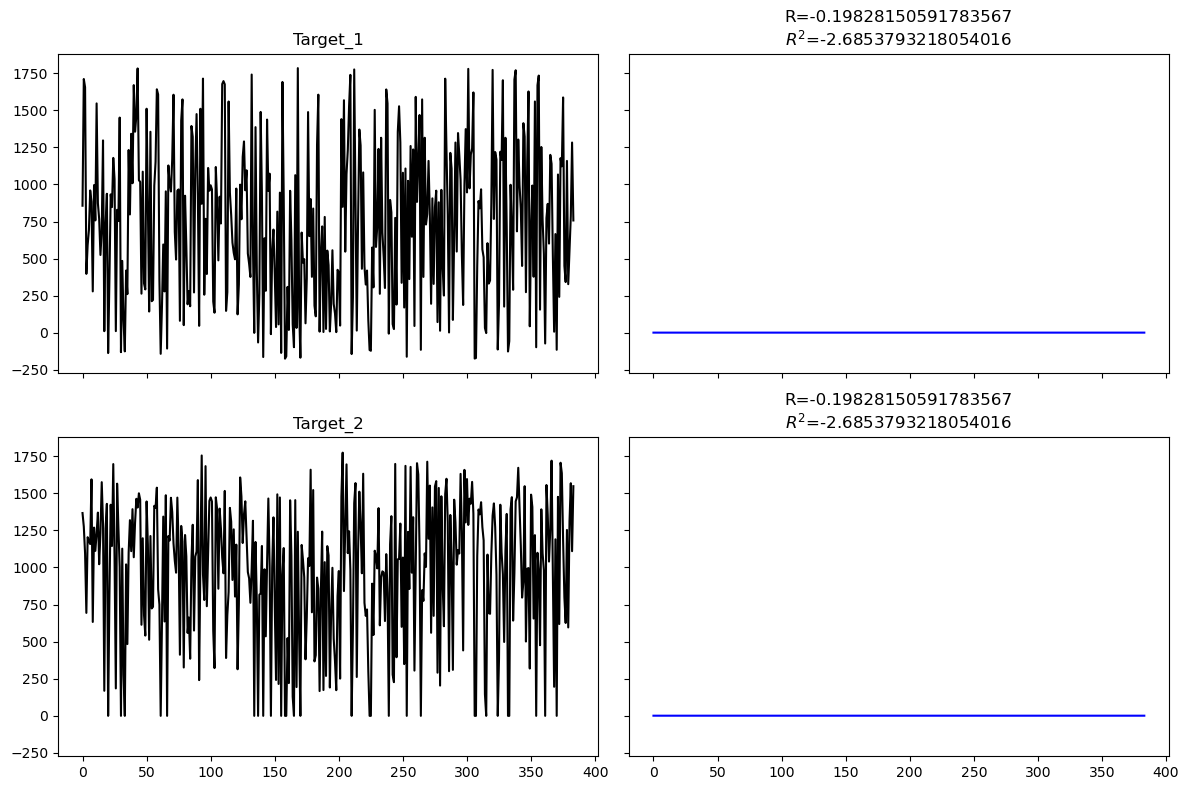

In [19]:
nom = engine_fis_str.split("__")[0]
GuardarFIS(fnom+"__final.fis",fis=engine_fis,modelo=engine_anfis_model)
print("Resultados con LM")
y_hat = engine_anfis_model(engine_X_test)
PlotTraining(engine_X_test,y_hat,engine_Y_test)

print("Resultados con ADAM")
y_hat_adam = engine_adam_model(engine_X_test)
PlotTraining(engine_X_test,y_hat_adam,engine_Y_test)

## Iris Data Set

In [20]:
#todos los datos
iris_datos = pd.read_csv("data_sets/iris/iris.data",header=None)

iris_in  = iris_datos.drop(columns=[4]).to_numpy()
iris_out = iris_datos[4].map({"Iris-setosa":0,"Iris-versicolor":1,"Iris-virginica":2}).to_numpy()

#separarlos en entrenamiento,validación y prueba
iris_X_train, iris_X_val, iris_y_train, iris_y_val = train_test_split(iris_in, 
                                                                    iris_out, 
                                                                    test_size=test_size)
iris_XTEST, iris_XVAL, iris_YTEST, iris_YVAL = train_test_split(iris_X_val, 
                                                                iris_y_val,
                                                                test_size=val_size)

### Encontrar las reglas

Cargando FIS
Entradas: 4 Salidas: 3 Reglas:3
sigma: torch.Size([4, 3])
centro: torch.Size([4, 3])
theta: torch.Size([3, 3])
MSELoss()
Inputs: torch.Size([90, 4]) , Outputs: torch.Size([90, 3])
Epoch 0, Loss: 37.568124
Epoch 100, Loss: 0.000000
Se llego a la tolerancia 0.000000 <= 1e-12
tensor([[16,  0,  0],
        [ 0, 17,  1],
        [ 0,  0, 14]])
Accuracy: 0.979
Precision: 0.978
Cargando FIS
Entradas: 4 Salidas: 3 Reglas:4
sigma: torch.Size([4, 4])
centro: torch.Size([4, 4])
theta: torch.Size([4, 3])
MSELoss()
Inputs: torch.Size([90, 4]) , Outputs: torch.Size([90, 3])
Epoch 0, Loss: 36.285564
Epoch 100, Loss: 0.000000
Se llego a la tolerancia 0.000000 <= 1e-12
tensor([[16,  0,  0],
        [ 0, 18,  0],
        [ 0,  1, 13]])
Accuracy: 0.979
Precision: 0.982
Cargando FIS
Entradas: 4 Salidas: 3 Reglas:5
sigma: torch.Size([4, 5])
centro: torch.Size([4, 5])
theta: torch.Size([5, 3])
MSELoss()
Inputs: torch.Size([90, 4]) , Outputs: torch.Size([90, 3])
Epoch 0, Loss: 25.566219
Epoch 10

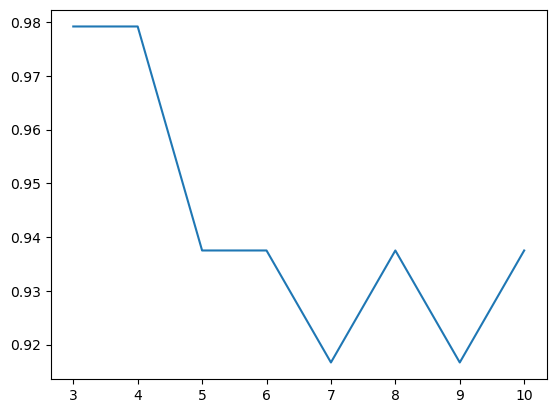

In [21]:
iris_best_reglas, iris_log = cantidad_reglas(entradas=4,
                                            salidas=3,
                                            n_clases=3,
                                            r_inicial=3,
                                            r_final=10,
                                            x_train=iris_X_train,
                                            y_train=iris_y_train,
                                            x_test=iris_XTEST,
                                            y_test=iris_YTEST)
print(f"Mejor cantidad de reglas: {iris_best_reglas}")
plt.plot(range(3,11),iris_log)

### Configuración del FIS IRIS

In [22]:
iris_n_in = 4
iris_n_out =  3    
iris_k_reglas = iris_best_reglas # o 3 reglas ya que es el menor del segundo mejor
iris_clases = 3  


### Convertir la entrada y target a tensores pytorch

In [23]:
iris_X = torch.from_numpy(iris_X_train).to(torch.float64)
iris_X_test = torch.from_numpy(iris_XTEST).to(torch.float64)

iris_X_VAL = torch.from_numpy(iris_XVAL).to(torch.float64)
iris_Y_VAL = torch.from_numpy(iris_YVAL).to(torch.float64)

iris_Y = torch.from_numpy(iris_y_train).to(torch.float64)
iris_Y_test = torch.from_numpy(iris_YTEST).to(torch.float64)


### Convertimos la entrada y target a tensores pytorch y 
### preprocesamos el target a ONEHOTENCODE

In [24]:
iris_X = torch.from_numpy(iris_X_train).to(torch.float64)
iris_X_test = torch.from_numpy(iris_XTEST).to(torch.float64)

iris_X_VAL = torch.from_numpy(iris_XVAL).to(torch.float64)
iris_Y_VAL = torch.from_numpy(iris_YVAL).to(torch.float64)

iris_Y = torch.from_numpy(iris_y_train).to(torch.float64)
iris_Y_test = torch.from_numpy(iris_YTEST).to(torch.float64)

#preprocesado del target al ONE HOT ENCODE
iris_Y = OneHotEncode(iris_Y,iris_clases)
iris_Y_test =  OneHotEncode(iris_Y_test,iris_clases)
iris_Y_VAL = OneHotEncode(iris_Y_VAL,iris_clases) 


#creamos el fis inicial con los target preprocesados
iris_fis,iris_fis_str= CrearFISInicial("iris", 
                                    pd.DataFrame(iris_X_train),
                                    pd.DataFrame(iris_Y.numpy().squeeze()),
                                    iris_k_reglas)


### Creamos modelo difuso del IRIS

In [25]:
""" Diferentes optimizadores
.AddOptimizador(SGD, lr=0.001,momentum=0,weight_decay=0,nesterov=False)
.AddOptimizador(RMSprop, lr=0.001,alpha=0.99,eps=1e-08,weight_decay=0,momentum=0,centered=False)
.AddOptimizador(Adam, lr=0.001,betas=(0.9,0.99),eps=1e-8) 
.AddOptimizador(LM, lambda_init=0.01,lambda_decr=0.9,lambda_incr=10) 

.AddFunctionLoss(MAE)
.AddFunctionLoss(MSE)
.AddFunctionLoss(SSE)
"""


iris_anfis_model =   RLANFISBuilder() \
                    .AddFIS(iris_fis_str) \
                    .AddInputs(iris_n_in) \
                    .AddOutputs(iris_n_out) \
                    .AddRules(iris_k_reglas) \
                    .AddValMaxFails(20) \
                    .AddTipoProblema("clasificacion") \
                    .AddOptimizador(LM, lambda_init=0.01,lambda_decr=0.9,lambda_incr=10) \
                    .AddFunctionLoss(SSE) \
                    .Build()

iris_adam_model =   RLANFISBuilder() \
                    .AddFIS(iris_fis_str) \
                    .AddInputs(iris_n_in) \
                    .AddOutputs(iris_n_out) \
                    .AddRules(iris_k_reglas) \
                    .AddValMaxFails(20) \
                    .AddTipoProblema("clasificacion") \
                    .AddOptimizador(Adam, lr=0.01,betas=(0.9,0.99),eps=1e-8)  \
                    .AddFunctionLoss(SSE) \
                    .Build()

Cargando FIS
Entradas: 4 Salidas: 3 Reglas:3
sigma: torch.Size([4, 3])
centro: torch.Size([4, 3])
theta: torch.Size([3, 3])
<function <lambda> at 0x309699300>
Cargando FIS
Entradas: 4 Salidas: 3 Reglas:3
sigma: torch.Size([4, 3])
centro: torch.Size([4, 3])
theta: torch.Size([3, 3])
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.99)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)
<function <lambda> at 0x309699300>


### Entrenamos el Modelo

Inputs: torch.Size([90, 4]) , Outputs: torch.Size([90, 3])
Epoch 0, Loss: 37.568124
Epoch 100, Loss: 0.000000
Se llego a la tolerancia 0.000000 <= 1e-12
Inputs: torch.Size([90, 4]) , Outputs: torch.Size([90, 3])
Epoch 0, Loss: 90.000000
Epoch 100, Loss: 5.889332
Epoch 200, Loss: 3.866134
Epoch 300, Loss: 3.866105
Epoch 400, Loss: 3.866087
Epoch 500, Loss: 3.866086
Epoch 600, Loss: 3.866081
Epoch 700, Loss: 3.866082
Epoch 800, Loss: 3.866106
Epoch 900, Loss: 3.866078


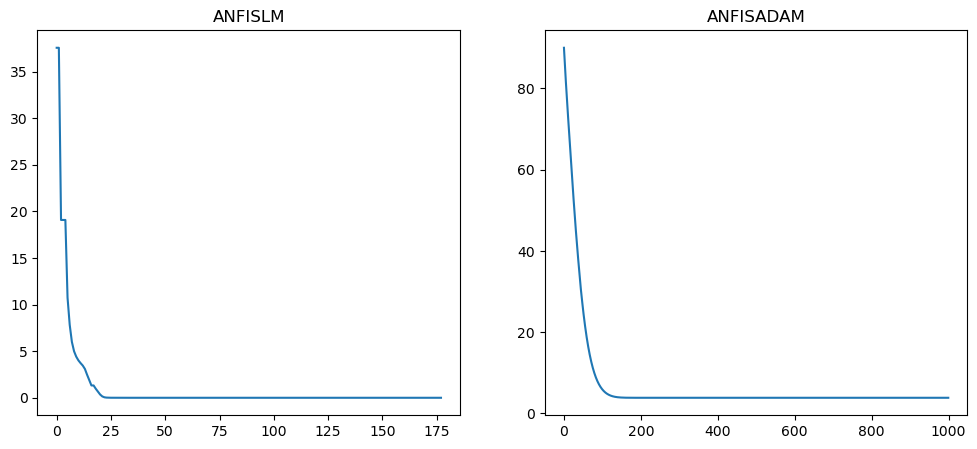

In [26]:
iris_loss = train_nfs(iris_anfis_model,                 #modelo
                        iris_X,                         #datos entrada
                        iris_Y,                         #datos target
                        epochs=1000,                    #número de épocas
                        tolerancia=1e-12)               #tolerancia del error

iris_adam_loss = train_nfs(iris_adam_model,                 #modelo
                        iris_X,                         #datos entrada
                        iris_Y,                         #datos target
                        epochs=1000,                    #número de épocas
                        tolerancia=1e-12)               #tolerancia del error

fig, axis = plt.subplots(1,2,figsize=(12,5))
axis[0].set_title("ANFISLM")
axis[0].plot(iris_loss)
axis[1].set_title("ANFISADAM")
axis[1].plot(iris_adam_loss)
plt.show()

### Mostramos resultados

Resultados con LM
tensor([[16,  0,  0],
        [ 0, 17,  1],
        [ 0,  0, 14]])
Accuracy: 0.979
Precision: 0.978


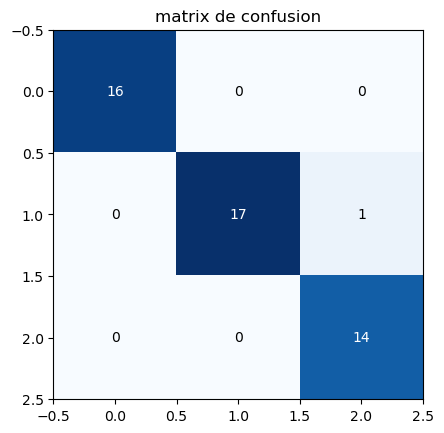

Resultados con ADAM
tensor([[16,  0,  0],
        [ 0, 17,  1],
        [ 0,  2, 12]])
Accuracy: 0.938
Precision: 0.939


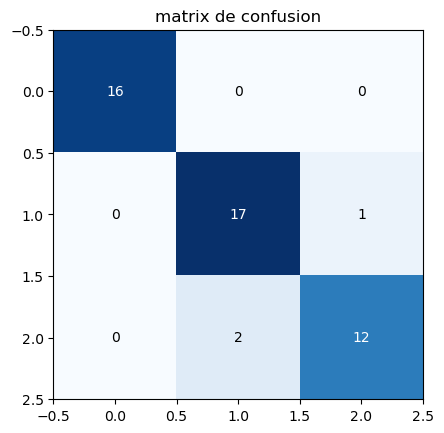

(0.9375, 0.9392712550607287)

In [27]:
fnom = iris_fis_str.split("__")[0]
GuardarFIS(fnom+"__final.fis",fis=iris_fis,modelo=iris_anfis_model)
print("Resultados con LM")
y_hat = iris_anfis_model(iris_X_test)
confusion_matrix(y_hat,
                iris_Y_test,
                num_classes=iris_clases,
                plot=True)

print("Resultados con ADAM")
y_hat_adam = iris_adam_model(iris_X_test)
confusion_matrix(y_hat_adam,
                iris_Y_test,
                num_classes=iris_clases,
                plot=True)

